In [4]:
from burau_package.classes.generators import Generators
from burau_package.classes.laurent_matrix import LaurentMatrix
from burau_package.scripts.free_scripts import calculate_products
from burau_package.scripts.free_scripts import tiered_sampling, min_invariant_in_array, largest_power_range, extend_in_all_ways_p, projlen
from burau_package.RL.env import BurauEnv
from stable_baselines3 import DQN,PPO,A2C
from stable_baselines3.common.callbacks import ProgressBarCallback


In [2]:
from burau_package.classes.generators import Generators
from burau_package.classes.laurent_matrix import LaurentMatrix

Here are generators A,a,B,b:

In [ ]:
gens = Generators() #creates generators object
A = gens.A 
a = gens.a
B = gens.B
b = gens.b
print(type(A))
print(A)
print(A*a)
print(A**10)
print(A*B*B*a*b)

<class 'burau_package.classes.laurent_matrix.LaurentMatrix'>
[
 [0, 0, -1.0x^-1],
 [0, -1.0x^1, 1.0x^1 + -1.0x^-1],
 [-1.0, 0, 1.0 + -1.0x^-1]
]
[
 [1.0, 0, 0],
 [0, 1.0, 0],
 [0, 0, 1.0]
]
[
 [1.0x^-1 + -1.0x^-2 + 1.0x^-3 + -1.0x^-4 + 1.0x^-5 + -1.0x^-6 + 1.0x^-7 + -1.0x^-8 + 1.0x^-9, 0, -1.0x^-1 + 1.0x^-2 + -1.0x^-3 + 1.0x^-4 + -1.0x^-5 + 1.0x^-6 + -1.0x^-7 + 1.0x^-8 + -1.0x^-9 + 1.0x^-10],
 [-1.0x^9 + 1.0x^8 + -1.0x^7 + 1.0x^6 + -1.0x^5 + 1.0x^4 + -1.0x^3 + 1.0x^2 + -1.0x^1 + 1.0x^-1 + -1.0x^-2 + 1.0x^-3 + -1.0x^-4 + 1.0x^-5 + -1.0x^-6 + 1.0x^-7 + -1.0x^-8 + 1.0x^-9, 1.0x^10, -1.0x^10 + 1.0x^9 + -1.0x^8 + 1.0x^7 + -1.0x^6 + 1.0x^5 + -1.0x^4 + 1.0x^3 + -1.0x^2 + 1.0x^1 + -1.0x^-1 + 1.0x^-2 + -1.0x^-3 + 1.0x^-4 + -1.0x^-5 + 1.0x^-6 + -1.0x^-7 + 1.0x^-8 + -1.0x^-9 + 1.0x^-10],
 [-1.0 + 1.0x^-1 + -1.0x^-2 + 1.0x^-3 + -1.0x^-4 + 1.0x^-5 + -1.0x^-6 + 1.0x^-7 + -1.0x^-8 + 1.0x^-9, 0, 1.0 + -1.0x^-1 + 1.0x^-2 + -1.0x^-3 + 1.0x^-4 + -1.0x^-5 + 1.0x^-6 + -1.0x^-7 + 1.0x^-8 + -1.0x^-9 + 1.0x^-

We can make their coordinates modulo k the following way:

In [ ]:
gens = Generators(mod= 2)
Amod2 = gens.A
print(Amod2)
print(projlen(Amod2))

Matrix (mod 2):
[
 [0 (mod 2), 0 (mod 2), 1x^-1 (mod 2)],
 [0 (mod 2), 1x^1 (mod 2), 1x^1 + 1x^-1 (mod 2)],
 [1 (mod 2), 0 (mod 2), 1 + 1x^-1 (mod 2)]
]
2


Algorithm that find identity mod 2:

In [6]:
from burau_package.scripts.free_scripts import calculate_products
mod = 2
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
k = 4
init_dict = calculate_products(base_dict.copy(), max_length=k) #calculate all words up to length k
#Some examples
print(init_dict["AABab"])
print(len(init_dict))

100%|██████████| 4/4 [00:01<00:00,  3.13it/s]

Matrix (mod 2):
[
 [1x^2 + 1x^1 + 1x^-1 + 1x^-2 (mod 2), 1x^2 + 1x^1 + 1x^-1 + 1x^-2 (mod 2), 1x^-3 (mod 2)],
 [1x^5 + 1x^4 + 1x^-1 + 1x^-2 (mod 2), 1x^5 + 1x^4 + 1x^-2 (mod 2), 1x^-1 + 1x^-3 (mod 2)],
 [1x^3 + 1x^2 + 1 + 1x^-1 + 1x^-2 (mod 2), 1x^3 + 1x^2 + 1 + 1x^-1 (mod 2), 1x^-2 + 1x^-3 (mod 2)]
]
484


Now, throw away all words of length less than max_length

In [7]:
init_dict= {key: value for key, value in init_dict.items() if len(key) == k} 

How, run selection process for some number of turns:

In [8]:
from burau_package.scripts.free_scripts import tiered_sampling, min_invariant_in_array, largest_power_range, extend_in_all_ways_p

In [ ]:
tiered_dict = init_dict.copy()
for i in range(340):
        #taking best m matrices (in principle there are different ways, but here it is enough)
        m = 1000
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m, invariant=projlen) 
        #extending tiered array
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        #printing info
        """
        "current length" "(minimal value of invariant, number of found indentities, dictionary of indentities)"
        """
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,projlen))
        #repeating

5 (6, 0, [])
6 (6, 0, [])
7 (6, 0, [])
8 (7, 0, [])
9 (8, 0, [])
10 (7, 0, [])
11 (8, 0, [])
12 (8, 0, [])
13 (8, 0, [])
14 (8, 0, [])
15 (9, 0, [])
16 (8, 0, [])
17 (6, 0, [])
18 (7, 0, [])
19 (8, 0, [])
20 (8, 0, [])
21 (8, 0, [])
22 (7, 0, [])
23 (6, 0, [])
24 (7, 0, [])
25 (6, 0, [])
26 (7, 0, [])
27 (6, 0, [])
28 (5, 0, [])
29 (4, 0, [])
30 (3, 0, [])
31 (2, 0, [])
32 (0, 6, ['BaaaBabbabbbbbabaBBBaBAABAAAAABA', 'bAAAbABBABBBBBABAbbbAbaabaaaaaba', 'abbbabAAbAAAAAbAbaaabaBBaBBBBBaB', 'bAbbbbbAbbABAAABaBaaaaaBaaBABBBA', 'abaaaaabaabAbbbABABBBBBABBAbAAAb', 'aBaaaaaBaaBABBBAbAbbbbbAbbABAAAB'])
33 (2, 0, [])


Process SpawnPoolWorker-543:
Process SpawnPoolWorker-540:
Process SpawnPoolWorker-541:
Process SpawnPoolWorker-538:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py", line 385, in

KeyboardInterrupt: 

In [ ]:
tiered_dict = init_dict.copy()
for i in range(31):
        #taking best m matrices (in principle there are different ways, but here it is enough)
        m = 10
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        #extending tiered array
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        #printing info
        """
        "current length" "(minimal value of invariant, number of found indentities, dictionary of indentities)"
        """
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        #repeating

2 (2, 0, [])
3 (2, 0, [])
4 (3, 0, [])
5 (3, 0, [])
6 (3, 0, [])
7 (4, 0, [])
8 (4, 0, [])
9 (4, 0, [])
10 (4, 0, [])
11 (4, 0, [])
12 (5, 0, [])
13 (5, 0, [])
14 (5, 0, [])
15 (5, 0, [])
16 (5, 0, [])
17 (5, 0, [])
18 (5, 0, [])
19 (5, 0, [])
20 (6, 0, [])
21 (5, 0, [])
22 (5, 0, [])
23 (6, 0, [])
24 (6, 0, [])
25 (6, 0, [])
26 (5, 0, [])
27 (5, 0, [])
28 (4, 0, [])
29 (4, 0, [])
30 (5, 0, [])
31 (5, 0, [])
32 (5, 0, [])


So m = 20000 enough to find word of length 32 (m = 10000 not enough), but to find word of length 34 even m = 10 is enough (even though not in every run)

In [ ]:
tiered_dict = init_dict.copy()
for i in range(25):
        m = 10
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))


10 (4, 0, [])
11 (4, 0, [])
12 (5, 0, [])
13 (5, 0, [])
14 (4, 0, [])
15 (5, 0, [])
16 (4, 0, [])
17 (3, 0, [])
18 (4, 0, [])
19 (5, 0, [])
20 (5, 0, [])
21 (5, 0, [])
22 (4, 0, [])
23 (4, 0, [])
24 (4, 0, [])
25 (4, 0, [])
26 (4, 0, [])
27 (3, 0, [])
28 (4, 0, [])
29 (4, 0, [])
30 (3, 0, [])
31 (2, 0, [])
32 (2, 0, [])
33 (1, 0, [])
34 (0, 1, ['AbAAAbAAbAAbAAAbAABAAABAABAABAAABA'])


Now, let's do the same modulo 3

In [14]:
mod = 5
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
k = 3
init_dict = calculate_products(base_dict.copy(), max_length=k) 
init_dict = {key: value for key, value in init_dict.items() if len(key) == k} 

100%|██████████| 3/3 [00:01<00:00,  2.03it/s]


In [ ]:

tiered_dict = init_dict.copy()
for i in range(10000):
        m = 10000
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m,invariant=projlen) 
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,projlen))



4 (5, 0, [])
5 (6, 0, [])
6 (6, 0, [])
7 (6, 0, [])
8 (7, 0, [])
9 (8, 0, [])
10 (7, 0, [])
11 (8, 0, [])
12 (8, 0, [])
13 (8, 0, [])
14 (8, 0, [])
15 (9, 0, [])
16 (9, 0, [])
17 (8, 0, [])
18 (9, 0, [])
19 (10, 0, [])
20 (9, 0, [])
21 (10, 0, [])
22 (10, 0, [])
23 (10, 0, [])
24 (9, 0, [])
25 (10, 0, [])
26 (10, 0, [])
27 (10, 0, [])
28 (10, 0, [])
29 (10, 0, [])
30 (10, 0, [])
31 (10, 0, [])
32 (11, 0, [])
33 (11, 0, [])
34 (10, 0, [])
35 (11, 0, [])
36 (11, 0, [])
37 (11, 0, [])
38 (11, 0, [])
39 (12, 0, [])
40 (11, 0, [])
41 (10, 0, [])
42 (11, 0, [])
43 (12, 0, [])
44 (11, 0, [])
45 (12, 0, [])
46 (12, 0, [])
47 (12, 0, [])
48 (11, 0, [])
49 (12, 0, [])
50 (12, 0, [])
51 (12, 0, [])
52 (12, 0, [])
53 (12, 0, [])
54 (12, 0, [])
55 (12, 0, [])
56 (12, 0, [])
57 (12, 0, [])
58 (11, 0, [])
59 (12, 0, [])
60 (12, 0, [])
61 (12, 0, [])
62 (12, 0, [])
63 (12, 0, [])
64 (12, 0, [])
65 (12, 0, [])
66 (12, 0, [])
67 (13, 0, [])
68 (13, 0, [])
69 (12, 0, [])
70 (12, 0, [])
71 (12, 0, [])
72 

In [ ]:
print(len("bAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAb"))

It found word of length 338

But for mod 5 it cannot find anything, even though the degree remains low during the search

In [10]:
from  tqdm import tqdm
tiered_dict = init_dict.copy()

for i in tqdm(range(1000000)):
        #taking best m matrices (in principle there are different ways, but here it is enough)
        m = 10000
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        #extending tiered array
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        #printing info
        """
        "current length" "(minimal value of invariant, number of found indentities, dictionary of indentities)"
        """
        #print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        if(min_invariant_in_array(tiered_dict,largest_power_range)[0] == 0):
                print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        #repeating

  0%|          | 1/1000000 [00:00<80:02:27,  3.47it/s]

4 (3, 0, [])


  0%|          | 2/1000000 [00:00<62:49:22,  4.42it/s]

5 (3, 0, [])


  0%|          | 3/1000000 [00:00<59:11:52,  4.69it/s]

...

367 (4, 0, [])


  0%|          | 365/1000000 [28:33<1875:59:20,  6.76s/it]

368 (5, 0, [])


Process SpawnPoolWorker-3533:
Process SpawnPoolWorker-3535:
Process SpawnPoolWorker-3534:
Process SpawnPoolWorker-3529:
Process SpawnPoolWorker-3528:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ~~~~^^^^^^^^^^^^^^^
  File "/opt

KeyboardInterrupt: 

In [ ]:
from burau_package.scripts.free_scripts import tiered_sampling, extend_in_all_ways_with_T
from burau_package.classes.laurent_matrix import LaurentMatrix
from tqdm import tqdm
mod = 3

T = LaurentMatrix([
                [-1, 1, 0],
                [-1, 0, 1],
                [-1, 0, 0]
            ], mod)

t = LaurentMatrix([
                [0, 0, -1],
                [1, 0, -1],
                [0, 1, -1]
            ], mod)
gens = Generators(mod)
T_dict = { 
        "B" : gens.B,
        "T" : T,
        "t" : t}


tiered_dict = T_dict.copy()
for i in range(1000):
        #taking best m matrices (in principle there are different ways, but here it is enough)
        m = 10000
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        #extending tiered array
        tiered_dict = extend_in_all_ways_with_T(T_dict,tiered_dict,1)
        #print(tiered_dict)
        #printing info
        """
        "current length" "(minimal value of invariant, number of found indentities, dictionary of indentities)"
        """
        #print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        #repeating

2 (1, 0, [])
3 (1, 0, [])
4 (2, 0, [])
5 (2, 0, [])
6 (2, 0, [])
7 (2, 0, [])
8 (3, 0, [])
9 (3, 0, [])
10 (3, 0, [])
11 (3, 0, [])
12 (3, 0, [])
13 (3, 0, [])
14 (4, 0, [])
15 (4, 0, [])
16 (4, 0, [])
17 (4, 0, [])
18 (4, 0, [])
19 (4, 0, [])
20 (4, 0, [])
21 (4, 0, [])
22 (4, 0, [])
23 (4, 0, [])
24 (4, 0, [])
25 (4, 0, [])
26 (5, 0, [])
27 (4, 0, [])
28 (4, 0, [])
29 (4, 0, [])
30 (5, 0, [])
31 (5, 0, [])
32 (5, 0, [])
33 (5, 0, [])
34 (5, 0, [])
35 (5, 0, [])
36 (5, 0, [])
37 (5, 0, [])
38 (5, 0, [])
39 (5, 0, [])
40 (5, 0, [])
41 (5, 0, [])
42 (5, 0, [])
43 (5, 0, [])
44 (5, 0, [])
45 (5, 0, [])
46 (5, 0, [])
47 (5, 0, [])
48 (5, 0, [])
49 (5, 0, [])
50 (5, 0, [])
51 (5, 0, [])
52 (5, 0, [])
53 (5, 0, [])
54 (5, 0, [])
55 (5, 0, [])
56 (5, 0, [])
57 (5, 0, [])
58 (6, 0, [])
59 (6, 0, [])
60 (6, 0, [])
61 (6, 0, [])
62 (6, 0, [])
63 (6, 0, [])
64 (6, 0, [])
65 (5, 0, [])
66 (5, 0, [])
67 (5, 0, [])
68 (6, 0, [])
69 (6, 0, [])
70 (6, 0, [])
71 (6, 0, [])
72 (6, 0, [])
73 (6, 0, [])


In [29]:
s = "BBTBtBBBBBTBtBBBBTBtBBBBTBtBBBBBTBtBBtBTBtBBBTBtB"
print(s.count("B"))

34


Now idea is to apply RL to find a words for mod = 5, or even over \mathbb{Z}.

The environment is the following:

In [1]:
from burau_package.RL.env import BurauEnv

In [ ]:


#We have to specify mod and maximum length
mod = 2
max_len = 32
env = BurauEnv(mod = mod,obs = max_len)
env.render()
#Action space is 0,1,2,3 which is applying correspondning letters
#Note than what is stored in step is +1 of what is the real action

print(env.step(0))
env.render()
# The reward is +1 if degree is decreased, -1 if increased, -100 if made inverse
print(env.step(1))
env.render()
print(env.step(2))
env.render()




[Turn 0] word = (empty)
([1, 0, 0, 1, 0, 1, 1, 0, 0, 1], -1, False, False, {})
[Turn 1] word = A
([2, 0, 1, 0, 0, 1, 2, 1, 1, 1], -1, False, False, {})
[Turn 2] word = AB
([2, 0, 1, 1, 0, 2, 3, 2, 1, 2], -1, False, False, {})
[Turn 3] word = ABB
[1 1 0 1]


Let's now try to run basic DQN from SB3

In [1]:
from stable_baselines3 import DQN,PPO,A2C
from stable_baselines3.common.callbacks import ProgressBarCallback
from stable_baselines3.common.evaluation import evaluate_policy
from burau_package.RL.env import BurauEnv
from stable_baselines3.common.utils import configure_logger

In [2]:
env = BurauEnv(mod=2,obs=34)
params = {'learning_rate': 0.002986116647163245, 'n_steps': 129, 'gamma': 0.9768807735611892, 'gae_lambda': 0.8647064024023551, 'ent_coef': 0.008036920932833659, 'clip_range': 0.2662186896910582}
model = PPO("MlpPolicy", env, verbose=0, **params)

model.learn(total_timesteps=10000,progress_bar=True)


/opt/homebrew/lib/python3.13/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 64, but because the `RolloutBuffer` is of size `n_steps * n_envs = 129`, after every 2 untruncated mini-batches, there will be a truncated mini-batch of size 1
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=129 and n_envs=1)
  warnings.warn(


Output()

In [4]:
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

# Import your env
# from burau_package.envs.burau_env import BurauEnv  # or whatever the path is

def make_env():
    # Same env you used before
    return BurauEnv(mod=2, obs=34)

def objective(trial: optuna.Trial) -> float:
    # ----- Sample hyperparameters -----
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 3e-3, log=True)
    n_steps       = trial.suggest_int("n_steps", 64, 2048, log=True)
    gamma         = trial.suggest_float("gamma", 0.90, 0.999, log=True)
    gae_lambda    = trial.suggest_float("gae_lambda", 0.8, 1.0)
    ent_coef      = trial.suggest_float("ent_coef", 0.0, 0.05)
    clip_range    = trial.suggest_float("clip_range", 0.1, 0.4)

    env = make_env()
    mean_rewards = 0
    for i in range(5):
        model = PPO(
            "MlpPolicy",
            env,
            learning_rate=learning_rate,
            n_steps=n_steps,
            gamma=gamma,
            gae_lambda=gae_lambda,
            ent_coef=ent_coef,
            clip_range=clip_range,
            verbose=0,              # keep silent during tuning
        )

        # Train for some fixed budget per trial
        model.learn(total_timesteps=100_000, progress_bar=False)

        # Evaluate the trained model
        mean_reward, _ = evaluate_policy(
            model,
            env,
            n_eval_episodes=10,
            deterministic=True,
        )
        mean_rewards = (i*mean_rewards+mean_reward)/(i+1)

    env.close()
    # We want to maximize mean reward
    return mean_rewards

# Create and run the Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best trial:", study.best_trial.number)
print("Best mean reward:", study.best_value)
print("Best hyperparameters:", study.best_params)

[I 2025-12-07 11:20:39,565] A new study created in memory with name: no-name-326ab027-7e29-4583-aa8e-49a5306d5412
/opt/homebrew/lib/python3.13/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 64, but because the `RolloutBuffer` is of size `n_steps * n_envs = 299`, after every 4 untruncated mini-batches, there will be a truncated mini-batch of size 43
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=299 and n_envs=1)
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
[I 2025-12-07 11:26:18,844] Trial 0 finished with value: -9.8 and parameters: {'learning_rate': 0.00029852528451563697

KeyboardInterrupt: 

In [3]:
mean_reward, std_reward = evaluate_policy(
    model,
    env,
    n_eval_episodes=100,    # how many episodes to average over
    deterministic=True,    # use deterministic actions (usually for eval)
    render=False           # set True if you want to see episodes
)

print(f"Mean reward: {mean_reward} +/- {std_reward}")

/opt/homebrew/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward: -8.0 +/- 0.0


In [24]:
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

[Turn 34] word = abbabababbababbabababbabaBaBaaBaBB
10


But if we will run with too much episodes it will be worse

In [ ]:
env = BurauEnv(mod=2,obs=34)
model = DQN("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=1000000,progress_bar=True)


Output()

KeyboardInterrupt: 

In [5]:
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

[Turn 34] word = BabababaaaaaaaaaaaaaaaaaaaBAABABAb

27

Let's try to optimize hyperparameters using optuna

In [ ]:
import optuna
from stable_baselines3.common.evaluation import evaluate_policy

In [ ]:
def objective(trial):
    env = BurauEnv(mod=2, obs=34)

    params = dict(
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 3e-3, log=True),
        buffer_size=trial.suggest_int("buffer_size", 10_000, 300_000, step=1000),
        learning_starts=trial.suggest_int("learning_starts", 0, 20_000, step=1000),
        batch_size=trial.suggest_categorical("batch_size", [32,64, 128, 256, 512, 1024]),
        gamma=trial.suggest_float("gamma", 0.95, 0.9999),
        target_update_interval=trial.suggest_int("target_update_interval", 1_000, 20_000, step=1000),
        train_freq=trial.suggest_categorical("train_freq", [1, 4, 8]),  # steps
        exploration_fraction=trial.suggest_float("exploration_fraction", 0.05, 0.4),
        exploration_initial_eps=trial.suggest_float("exploration_initial_eps", 0.8, 1.0),
        exploration_final_eps=trial.suggest_float("exploration_final_eps", 0.01, 0.3),
        verbose=0,
        
    )
    total_timesteps=trial.suggest_int("total_timesteps", 50_000, 200000, step=10000)
    model = DQN("MlpPolicy", env, **params)
    model.learn(total_timesteps=total_timesteps)  # keep small for speed

    eval_env = BurauEnv(mod=2, obs=34)
    mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=5, deterministic=True)
    eval_env.close()
    env.close()
    return mean_reward  # Optuna will MAXIMIZE this
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=500, n_jobs=8)  # change n_trials as you like

print("Best mean reward:", study.best_value)
print("Best params:", study.best_params)



[I 2025-09-14 10:07:12,816] A new study created in memory with name: no-name-96cec471-c1d3-4e2d-907a-3fca519838cd
/opt/homebrew/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
[I 2025-09-14 11:46:09,599] Trial 4 finished with value: -19.0 and parameters: {'learning_rate': 1.3333148490445958e-05, 'buffer_size': 43000, 'learning_starts': 15000, 'batch_size': 1024, 'gamma': 0.9856823341996652, 'target_update_interval': 13000, 'train_freq': 4, 'exploration_fraction': 0.11108845646751159, 'exploration_initial_eps': 0.8157804784309817, 'exploration_final_eps': 0.2726623016301785, 'total_timesteps': 110000}. Best is trial 4 with value: -19.0.
[I 2025-09-14 13:59:22,121] Trial 6 finished with value: -20.0 an

Best mean reward: -6.0
Best params: {'learning_rate': 2.233990531449866e-05, 'buffer_size': 298000, 'learning_starts': 2000, 'batch_size': 128, 'gamma': 0.9718909936789241, 'target_update_interval': 12000, 'train_freq': 4, 'exploration_fraction': 0.1258984654057439, 'exploration_initial_eps': 0.8667922055454196, 'exploration_final_eps': 0.07943696883310046, 'total_timesteps': 120000}


In [ ]:
best_params = {'learning_rate': 2.233990531449866e-05, 'buffer_size': 298000, 'learning_starts': 2000, 'batch_size': 128, 'gamma': 0.9718909936789241, 'target_update_interval': 12000, 'train_freq': 4, 'exploration_fraction': 0.1258984654057439, 'exploration_initial_eps': 0.8667922055454196, 'exploration_final_eps': 0.07943696883310046}
env = BurauEnv(mod=2, obs=34)
model_params = dict(256,256)
model = DQN("MlpPolicy", env, **best_params)
model.learn(total_timesteps=1000000,progress_bar=True)


TypeError: dict expected at most 1 argument, got 2

In [ ]:
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

[Turn 34] word = aBaababaababaabababaabababaaaabaBA
13


In [ ]:
from burau_package.RL.dqn import dqn
from burau_package.RL.env import BurauEnv
env = BurauEnv(mod=2,obs=34)
dqn(modulo=2,max_steps=34)

  2%|▏         | 1005/50000 [00:20<16:36, 49.19it/s]

[Episode   1000] AvgReward=-29.070, AvgLoss=20.49533, FinalWord=[4, 2, 2, 1, 2, 4, 2, 1, 1, 1, 2, 4, 3, 1, 3, 4, 3, 1, 1, 2, 1, 2, 2, 1, 3, 3, 3, 4, 3, 3, 3, 1, 3, 3], MaxPowerRange=24, Wins=0%, Loses=0%, Timeouts=0%


  4%|▍         | 2006/50000 [00:41<17:32, 45.59it/s]

[Episode   2000] AvgReward=-23.820, AvgLoss=5.49357, FinalWord=[2, 4, 4, 2, 4, 4, 3, 4, 4, 4, 4, 2, 1, 1, 3, 1, 2, 1, 1, 3, 4, 2, 2, 1, 3, 3, 4, 3, 1, 3, 3, 1, 1, 3], MaxPowerRange=28, Wins=0%, Loses=0%, Timeouts=0%


  6%|▌         | 3005/50000 [01:02<16:02, 48.83it/s]

...

[Episode  48000] AvgReward=-11.870, AvgLoss=0.06479, FinalWord=[4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 2, 4, 3], MaxPowerRange=8, Wins=0%, Loses=0%, Timeouts=0%


 98%|█████████▊| 49007/50000 [17:30<00:21, 46.48it/s]

[Episode  49000] AvgReward=-5.420, AvgLoss=0.06345, FinalWord=[1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1], MaxPowerRange=4, Wins=0%, Loses=0%, Timeouts=0%


100%|██████████| 50000/50000 [17:52<00:00, 46.62it/s]


[Episode  50000] AvgReward=-1.210, AvgLoss=0.06717, FinalWord=[1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1], MaxPowerRange=0, Wins=0%, Loses=0%, Timeouts=0%


In [ ]:
from burau_package.RL.dqn import dqn
from burau_package.RL.env import BurauEnv
env = BurauEnv(mod=2,obs=32)
dqn(modulo=2,max_steps=32, num_episodes=200000)

  1%|          | 1009/200000 [00:17<53:02, 62.53it/s] 

[Turn 32] word = aBaaBBBBBAbbaababbABBABaaabbbaba
[Episode   1000] AvgReward=-3.010, AvgLoss=40.00930, FinalWord=[4, 2, 4, 4, 2, 2, 2, 2, 2, 1, 3, 3, 4, 4, 3, 4, 3, 3, 1, 2, 2, 1, 2, 4, 4, 4, 3, 3, 3, 4, 3, 4], MaxPowerRange=23, Wins=0%, Loses=0%, Timeouts=0%


  1%|          | 2006/200000 [00:35<1:01:16, 53.86it/s]

[Turn 32] word = BabABAbbAbbAbaBBABAABAAAbbbABAbb
[Episode   2000] AvgReward=8.940, AvgLoss=20.70007, FinalWord=[2, 4, 3, 1, 2, 1, 3, 3, 1, 3, 3, 1, 3, 4, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 3, 3, 3, 1, 2, 1, 3, 3], MaxPowerRange=22, Wins=0%, Loses=0%, Timeouts=0%


  2%|▏         | 3008/200000 [00:53<1:01:26, 53.43it/s]

...

[Turn 32] word = bAbAAbAbAAbAbAAbAbAAbAAbAbAAbAbA
[Episode 198000] AvgReward=26.150, AvgLoss=0.07553, FinalWord=[3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1], MaxPowerRange=7, Wins=0%, Loses=0%, Timeouts=0%


100%|█████████▉| 199004/200000 [2:01:43<00:25, 38.36it/s]

[Turn 32] word = bAAbAbAAbAbAAbAbAAbAAbAbAAbAbAAb
[Episode 199000] AvgReward=26.210, AvgLoss=0.12194, FinalWord=[3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3], MaxPowerRange=7, Wins=0%, Loses=0%, Timeouts=0%


100%|██████████| 200000/200000 [2:02:09<00:00, 27.29it/s]


[Turn 32] word = aBAbAAbAbAAbAbAAbAbAAbAAbAbABABB
[Episode 200000] AvgReward=25.690, AvgLoss=0.09367, FinalWord=[4, 2, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 1, 3, 1, 3, 1, 2, 1, 2, 2], MaxPowerRange=7, Wins=0%, Loses=0%, Timeouts=0%


Output()

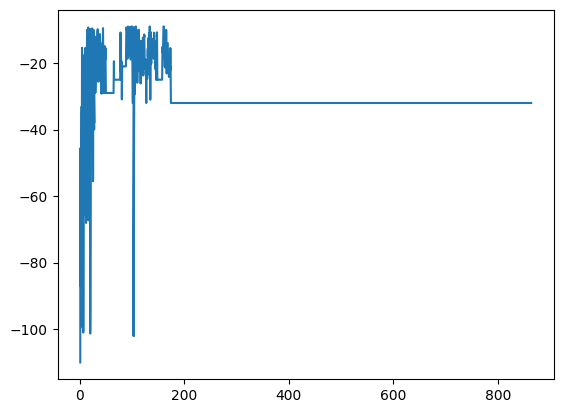

In [ ]:
from stable_baselines3 import A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results
import matplotlib.pyplot as plt
import os
import pandas as pd, glob, matplotlib.pyplot as plt

log_dir = "./logs_a2c"
os.makedirs(log_dir, exist_ok=True)

# 1) wrap env to log episode rewards/timesteps
env = Monitor(BurauEnv(mod=2, obs=32), log_dir)

# 2) train as usual
model = A2C("MlpPolicy", env, verbose=0, learning_rate=0.01, ent_coef=0.1)
model.learn(total_timesteps=2000000,progress_bar=True)

df = pd.concat([pd.read_csv(f, skiprows=1) for f in glob.glob(f"{log_dir}/*monitor*.csv")]).sort_values("t")
df["r_mean_50"] = df["r"].rolling(50, min_periods=1).mean()
plt.plot(df["t"], df["r_mean_50"]); plt.show()

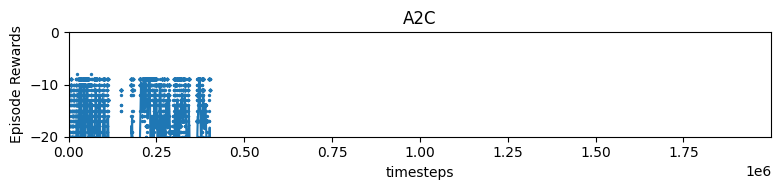

In [ ]:
plot_results([log_dir], num_timesteps=None, x_axis="timesteps", task_name="A2C")
ax = plt.gca()
ax.set_ylim(-20, 0)
plt.show()

In [ ]:
env = BurauEnv(mod=2,obs=32)
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

In [ ]:
from burau_package.RL.env import BurauEnv
from burau_package.RL.MCTS import mcts_search
from burau_package.scripts.free_scripts import tiered_sampling, min_invariant_in_array, largest_power_range, extend_in_all_ways_p

In [ ]:
max_steps = 32
env = BurauEnv(mod=2,obs=max_steps, reward_fun="old")
total_reward = 0
for _ in range(max_steps):
    action = mcts_search(env, reward=total_reward,iterations = 10)
    _, reward, _, _, _ = env.step(action)
    total_reward += reward
    env.render()
print(largest_power_range(env.matrix))


[Turn 1] word = a
[Turn 2] word = aB
[Turn 3] word = aBB
[Turn 4] word = aBBB
[Turn 5] word = aBBBB
[Turn 6] word = aBBBBB
[Turn 7] word = aBBBBBa
[Turn 8] word = aBBBBBaB
[Turn 9] word = aBBBBBaBB
[Turn 10] word = aBBBBBaBBa
[Turn 11] word = aBBBBBaBBab
[Turn 12] word = aBBBBBaBBaba
[Turn 13] word = aBBBBBaBBabaa
[Turn 14] word = aBBBBBaBBabaaa
[Turn 15] word = aBBBBBaBBabaaab
[Turn 16] word = aBBBBBaBBabaaabA
[Turn 17] word = aBBBBBaBBabaaabAb
[Turn 18] word = aBBBBBaBBabaaabAbA
[Turn 19] word = aBBBBBaBBabaaabAbAA
[Turn 20] word = aBBBBBaBBabaaabAbAAA
[Turn 21] word = aBBBBBaBBabaaabAbAAAA
[Turn 22] word = aBBBBBaBBabaaabAbAAAAA
[Turn 23] word = aBBBBBaBBabaaabAbAAAAAb
[Turn 24] word = aBBBBBaBBabaaabAbAAAAAbA
[Turn 25] word = aBBBBBaBBabaaabAbAAAAAbAA
[Turn 26] word = aBBBBBaBBabaaabAbAAAAAbAAb
[Turn 27] word = aBBBBBaBBabaaabAbAAAAAbAAba
[Turn 28] word = aBBBBBaBBabaaabAbAAAAAbAAbab
[Turn 29] word = aBBBBBaBBabaaabAbAAAAAbAAbabb
[Turn 30] word = aBBBBBaBBabaaabAbAAAAAbAAbabbb
[Tur

In [ ]:
import optuna
def objective(trial):
    c = trial.suggest_float("uct_c", 0.1, 3.0, log=True),     
    max_steps = 32

    avg_reward = 0
    for _ in range(10):
        env = BurauEnv(mod=2,obs=max_steps, reward_fun="old")
        total_reward = 0
        for _ in range(max_steps):
            action = mcts_search(env, reward=total_reward,iterations = 10, c = float(c[0]))
            _, reward, _, _, _ = env.step(action)
            total_reward += reward
        avg_reward += largest_power_range(env.matrix)
    avg_reward = avg_reward/10
    return avg_reward
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, n_jobs=8)  # change n_trials as you like

print("Best mean reward:", study.best_value)
print("Best params:", study.best_params)



[I 2025-10-05 16:07:05,565] Trial 89 finished with value: 14.2 and parameters: {'uct_c': 2.3104605367112683}. Best is trial 63 with value: 13.5.


In [18]:
def replace_word(word, replace_dict):
    return ''.join(replace_dict.get(ch, ch) for ch in word)
        

In [16]:
from burau_package.scripts.free_scripts import word_to_matrix
import random
mod = None
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
def get_degree_of_word(word,dict = base_dict):
    matrix = word_to_matrix(dict,word=word)
    return matrix, largest_power_range(matrix)

def random_reduced_word(max_len: int) -> str:
    letters = ['A', 'B', 'a', 'b']
    inverses = {'A': 'a', 'a': 'A', 'B': 'b', 'b': 'B'}

    word = []
    for _ in range(random.randint(1, max_len)):
        choices = [l for l in letters if not word or l != inverses[word[-1]]]
        word.append(random.choice(choices))
    return ''.join(word)
    

In [17]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(100):
        if(i % 10000 == 0):
              print(i)
              print(word)
        word = random_reduced_word(max_len = 50)
        
        mat1 , deg1 = get_degree_of_word(word)
        replace_dict = {"b":"b","B":"B","A":"a","a":"A"}

        word = replace_word(word,replace_dict)
        mat2 , deg2 = get_degree_of_word(word)
        print(word)
        if deg1 != deg2 and ('B' in word or 'b' in word):
            print(i,word, deg1, deg2)
            break



0


NameError: name 'word' is not defined

In [ ]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(1000000):
        if(i % 10000 == 0):
              print(i)
              print(word)
        word = random_reduced_word(max_len = 50)
        mat1 , deg1 = get_degree_of_word(word)
        replace_dict = {"b":"b","B":"B","A":"a","a":"A"}

        word = replace_word(word,replace_dict)
        mat2 , deg2 = get_degree_of_word(word)
        if deg1 != deg2 and ('B' in word or 'b' in word):
            print(i,word, deg1, deg2)
            break



0


NameError: name 'word' is not defined

In [5]:


word = "aa"
mat1 , deg1 = get_degree_of_word(word)
print(mat1.matrix[0][0])


NameError: name 'get_degree_of_word' is not defined

In [4]:
def power_image(matrix):
    powers = [[max(abs(entry.min_power), abs(entry.min_power + len(entry.coefficients) - 1)) for entry in row] for row in matrix.matrix]
    return powers

In [14]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(10):
        if(i % 10000 == 0):
              print(i)
              print(word)
        word = random_reduced_word(max_len = 5)
        mat1 , deg1 = get_degree_of_word(word)
        print(word,mat1)
        replace_dict = {"b":"b","B":"B","A":"a","a":"A"}

        word = replace_word(word,replace_dict)
        mat2 , deg2 = get_degree_of_word(word)
        print(word,mat2)
        if deg1 != deg2 and ('B' in word or 'b' in word):
            print(i,word, deg1, deg2)
            break



0


NameError: name 'word' is not defined

In [13]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(10):
      if(i % 10000 == 0):
            print(i)
            print(word)
      word = random_reduced_word(max_len = 30)
      mat1 , deg1 = get_degree_of_word(word)
      print(word)
      print(mat1.matrix[0][0]+mat1.matrix[1][1]+mat1.matrix[2][2])
      replace_dict = {"b":"B","B":"b","A":"A","a":"a"}

      word = replace_word(word,replace_dict)
      mat2 , deg2 = get_degree_of_word(word)
      print(word)
      print(mat2.matrix[0][0]+mat2.matrix[1][1]+mat2.matrix[2][2])
      print("\n\n\n")



0


NameError: name 'word' is not defined

In [10]:
word = "BA"
mat1 , deg1 = get_degree_of_word(word)
print(power_image(mat1))
replace_dict = {"b":"B","B":"b","A":"A","a":"a"}

word = replace_word(word,replace_dict)
mat2 , deg2 = get_degree_of_word(word)
print(power_image(mat2))

[[0, 1, 2], [0, 1, 1], [1, 1, 1]]
[[0, 2, 2], [0, 1, 1], [1, 0, 1]]


In [ ]:
mod = 3
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
transformed_dict = {"A" : gens.A*gens.B,
        "a" : gens.b*gens.a, 
        "B" : gens.B,
        "b" : gens.b}

    

In [3]:
for i in range(1):
      word = "bAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABA"
      mat1 , deg1 = get_degree_of_word(word, dict=base_dict)
      print(word)
      for row in power_image(mat1):
            print(row)

      mat2 , deg2 = get_degree_of_word(word,dict = transformed_dict)
      print(word)
      for row in power_image(mat2):
            print(row)
      print("\n\n\n")

NameError: name 'get_degree_of_word' is not defined

Trying to add transformation to extension in baseline algorithm

In [67]:
from burau_package.scripts.free_scripts import calculate_products
mod = 5
gens = Generators(mod)
base_dict = {"A" : gens.A*gens.A, 
        "a" : gens.a*gens.a, 
        "B" : gens.B*gens.B,
        "b" : gens.b*gens.b}
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
k = 8
init_dict = calculate_products(base_dict.copy(), max_length=k) #calculate all words up to length k

100%|██████████| 8/8 [00:04<00:00,  1.70it/s]


In [68]:
init_dict= {key: value for key, value in init_dict.items() if len(key) == k} 

In [69]:
def extend_by_transformations(base_dict,tiered_dict,replace_dict):
    new_words = {}
    for key, _ in tiered_dict.items():
        new_key = replace_word(key,replace_dict=replace_dict)
        if (new_key not in tiered_dict):
            mat, _ = get_degree_of_word(new_key,base_dict)
            new_words[new_key] = mat
        else:
            pass
    return tiered_dict | new_words

In [13]:
def split_in_half(s: str):
    """Return the two equal halves of a string.
       If length is odd, the second half will have one extra character."""
    mid = len(s) // 2
    return s[:mid], s[mid:]

a, b = split_in_half("bAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABA")
print(a)
print("\n")  
print(b) # abc d efgh  → 'abcd' 'efgh'

bAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbABAABAABABAABABAABAABABAABAABABAABAABABA


ABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABA


In [ ]:
mod = 2
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
matrix = word_to_matrix(base_dict,"AbAAAbAAbAAbAAAbAABAAABAABAABAAABA")
print(matrix)
matrix = word_to_matrix(base_dict,"ABAAAAABAABaBBBa")
print(matrix)

Matrix (mod 2):
[
 [1x^9 + 1x^7 + 1x^6 + 1x^5 + 1x^4 + 1 + 1x^-1 + 1x^-4 + 1x^-5 + 1x^-6 + 1x^-7 + 1x^-8 + 1x^-9 + 1x^-10 (mod 2), 1x^7 + 1x^1 + 1 + 1x^-2 + 1x^-4 + 1x^-5 + 1x^-6 + 1x^-8 + 1x^-10 (mod 2), 1x^8 + 1x^6 + 1x^2 + 1x^-2 + 1x^-3 + 1x^-5 + 1x^-6 + 1x^-8 + 1x^-9 (mod 2)],
 [1x^6 + 1x^5 + 1x^3 + 1x^1 + 1 + 1x^-2 + 1x^-3 + 1x^-5 + 1x^-6 + 1x^-7 (mod 2), 1x^4 + 1x^3 + 1x^2 + 1x^1 + 1 + 1x^-1 + 1x^-4 + 1x^-5 + 1x^-7 (mod 2), 1x^5 + 1x^4 + 1x^1 + 1 + 1x^-1 + 1x^-2 + 1x^-5 + 1x^-6 (mod 2)],
 [1x^9 + 1x^8 + 1x^6 + 1x^5 + 1x^3 + 1x^2 + 1x^1 + 1 + 1x^-2 + 1x^-6 + 1x^-10 (mod 2), 1x^7 + 1x^6 + 1x^5 + 1x^4 + 1x^1 + 1 + 1x^-3 + 1x^-4 + 1x^-5 + 1x^-7 + 1x^-8 + 1x^-9 + 1x^-10 (mod 2), 1x^8 + 1x^7 + 1x^4 + 1x^3 + 1x^2 + 1x^1 + 1 + 1x^-4 + 1x^-5 + 1x^-6 + 1x^-7 + 1x^-9 (mod 2)]
]
Matrix (mod 2):
[
 [1x^6 + 1x^5 + 1x^2 (mod 2), 1x^6 + 1x^2 + 1 + 1x^-1 (mod 2), 1x^4 + 1x^1 (mod 2)],
 [1x^6 + 1x^5 + 1x^4 + 1x^3 + 1x^2 + 1x^1 + 1 + 1x^-3 (mod 2), 1x^6 + 1x^4 + 1x^2 + 1x^1 + 1 + 1x^-1 + 1x^-2 + 1x

In [74]:
from tqdm import tqdm

L = ['A', 'a', 'B']

def total_words(max_len):
    return (3**(max_len+1)) - 3   # sum of 3^k for k=1..max_len

def all_words(max_len):
    total = total_words(max_len)
    stack = [""]                 # constant memory (DFS)

    with tqdm(total=total, unit="word") as bar:
        while stack:
            w = stack.pop()
            if len(w) < max_len:
                for c in reversed(L):     # DFS, constant stack size
                    nw = w + c

                    # forbid 'Aa' and 'aA' as consecutive letters
                    if "Aa" in nw or "aA" in nw:
                        continue

                    # your original processing
                    word = nw + nw.replace("b","B")
                    print(word)
                    m = word_to_matrix(base_dict, word)
                    if (largest_power_range(m) == 0 and nw[-1] != nw[0]):
                        print(word)

                    bar.update(1)
                    stack.append(nw)

all_words(16)

  0%|          | 72/129140160 [00:00<130:07:16, 275.68word/s]

BB
aa
AA
ABAB
AAAA
AABAAB
AAAAAA
AAABAAAB
AAAAAAAA
AAAABAAAAB
AAAAAAAAAA
AAAAABAAAAAB
AAAAAAAAAAAA
AAAAAABAAAAAAB
AAAAAAAAAAAAAA
AAAAAAABAAAAAAAB
AAAAAAAAAAAAAAAA
AAAAAAAABAAAAAAAAB
AAAAAAAAAAAAAAAAAA
AAAAAAAAABAAAAAAAAAB
AAAAAAAAAAAAAAAAAAAA
AAAAAAAAAABAAAAAAAAAAB
AAAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAABAAAAAAAAAAAB
AAAAAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAABAAAAAAAAAAAAB
AAAAAAAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAABAAAAAAAAAAAAAB
AAAAAAAAAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAABAAAAAAAAAAAAAAB
AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAAABAAAAAAAAAAAAAAAB
AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAABBAAAAAAAAAAAAAABB
AAAAAAAAAAAAAABaAAAAAAAAAAAAAABa
AAAAAAAAAAAAAABAAAAAAAAAAAAAAABA
AAAAAAAAAAAAABBAAAAAAAAAAAAABB
AAAAAAAAAAAAABaAAAAAAAAAAAAABa
AAAAAAAAAAAAABAAAAAAAAAAAAAABA
AAAAAAAAAAAAABABAAAAAAAAAAAAABAB
AAAAAAAAAAAAABAAAAAAAAAAAAAAABAA
AAAAAAAAAAAAABaBAAAAAAAAAAAAABaB
AAAAAAAAAAAAABaaAAAAAAAAAAAAABaa
AAAAAAAAAAAAABBBAAAAAAAAAAAAABBB
AAAAAAAAAAAAABBaAAAAAAAAAAAAABBa
AAAAAAAAAAAAABBAAAAAAAAAAAAAABB

  0%|          | 180/129140160 [00:00<145:27:56, 246.60word/s]

AAAAAAAAAAABaaBBAAAAAAAAAAABaaBB
AAAAAAAAAAABaaBaAAAAAAAAAAABaaBa
AAAAAAAAAAABaaBAAAAAAAAAAAABaaBA
AAAAAAAAAAABaBBAAAAAAAAAAABaBB
AAAAAAAAAAABaBaAAAAAAAAAAABaBa
AAAAAAAAAAABaBAAAAAAAAAAAABaBA
AAAAAAAAAAABaBABAAAAAAAAAAABaBAB
AAAAAAAAAAABaBAAAAAAAAAAAAABaBAA
AAAAAAAAAAABaBaBAAAAAAAAAAABaBaB
AAAAAAAAAAABaBaaAAAAAAAAAAABaBaa
AAAAAAAAAAABaBBBAAAAAAAAAAABaBBB
AAAAAAAAAAABaBBaAAAAAAAAAAABaBBa
AAAAAAAAAAABaBBAAAAAAAAAAAABaBBA
AAAAAAAAAAABBBAAAAAAAAAAABBB
AAAAAAAAAAABBaAAAAAAAAAAABBa
AAAAAAAAAAABBAAAAAAAAAAAABBA
AAAAAAAAAAABBABAAAAAAAAAAABBAB
AAAAAAAAAAABBAAAAAAAAAAAAABBAA
AAAAAAAAAAABBAABAAAAAAAAAAABBAAB
AAAAAAAAAAABBAAAAAAAAAAAAAABBAAA
AAAAAAAAAAABBABBAAAAAAAAAAABBABB
AAAAAAAAAAABBABaAAAAAAAAAAABBABa
AAAAAAAAAAABBABAAAAAAAAAAAABBABA
AAAAAAAAAAABBaBAAAAAAAAAAABBaB
AAAAAAAAAAABBaaAAAAAAAAAAABBaa
AAAAAAAAAAABBaaBAAAAAAAAAAABBaaB
AAAAAAAAAAABBaaaAAAAAAAAAAABBaaa
AAAAAAAAAAABBaBBAAAAAAAAAAABBaBB
AAAAAAAAAAABBaBaAAAAAAAAAAABBaBa
AAAAAAAAAAABBaBAAAAAAAAAAAABBaBA
AAAAAAAAAAABBBBAAAAAAAAAAABBBB
AAAAA

  0%|          | 230/129140160 [00:00<148:50:58, 241.00word/s]

...

  0%|          | 1933/129140160 [00:08<149:14:55, 240.35word/s]

AAAAAAABAABABaaBAAAAAAABAABABaaB
AAAAAAABAABABaaaAAAAAAABAABABaaa
AAAAAAABAABABaBBAAAAAAABAABABaBB
AAAAAAABAABABaBaAAAAAAABAABABaBa
AAAAAAABAABABaBAAAAAAAABAABABaBA
AAAAAAABAABABBBAAAAAAABAABABBB
AAAAAAABAABABBaAAAAAAABAABABBa
AAAAAAABAABABBAAAAAAAABAABABBA
AAAAAAABAABABBABAAAAAAABAABABBAB
AAAAAAABAABABBAAAAAAAAABAABABBAA
AAAAAAABAABABBaBAAAAAAABAABABBaB
AAAAAAABAABABBaaAAAAAAABAABABBaa
AAAAAAABAABABBBBAAAAAAABAABABBBB
AAAAAAABAABABBBaAAAAAAABAABABBBa
AAAAAAABAABABBBAAAAAAAABAABABBBA
AAAAAAABAABaBAAAAAAABAABaB
AAAAAAABAABaaAAAAAAABAABaa
AAAAAAABAABaaBAAAAAAABAABaaB
AAAAAAABAABaaaAAAAAAABAABaaa
AAAAAAABAABaaaBAAAAAAABAABaaaB
AAAAAAABAABaaaaAAAAAAABAABaaaa
AAAAAAABAABaaaaBAAAAAAABAABaaaaB
AAAAAAABAABaaaaaAAAAAAABAABaaaaa
AAAAAAABAABaaaBBAAAAAAABAABaaaBB
AAAAAAABAABaaaBaAAAAAAABAABaaaBa
AAAAAAABAABaaaBAAAAAAAABAABaaaBA
AAAAAAABAABaaBBAAAAAAABAABaaBB
AAAAAAABAABaaBaAAAAAAABAABaaBa
AAAAAAABAABaaBAAAAAAAABAABaaBA
AAAAAAABAABaaBABAAAAAAABAABaaBAB
AAAAAAABAABaaBAAAAAAAAABAABaaBAA
AAAAAAABAABaa

  0%|          | 1957/129140160 [00:08<149:13:23, 240.39word/s]


AAAAAAABAABBABBAAAAAAABAABBABB
AAAAAAABAABBABaAAAAAAABAABBABa
AAAAAAABAABBABAAAAAAAABAABBABA
AAAAAAABAABBABABAAAAAAABAABBABAB
AAAAAAABAABBABAAAAAAAAABAABBABAA
AAAAAAABAABBABaBAAAAAAABAABBABaB
AAAAAAABAABBABaaAAAAAAABAABBABaa
AAAAAAABAABBABBBAAAAAAABAABBABBB
AAAAAAABAABBABBaAAAAAAABAABBABBa
AAAAAAABAABBABBAAAAAAAABAABBABBA
AAAAAAABAABBaBAAAAAAABAABBaB
AAAAAAABAABBaaAAAAAAABAABBaa
AAAAAAABAABBaaBAAAAAAABAABBaaB
AAAAAAABAABBaaaAAAAAAABAABBaaa
AAAAAAABAABBaaaBAAAAAAABAABBaaaB
AAAAAAABAABBaaaaAAAAAAABAABBaaaa
AAAAAAABAABBaaBBAAAAAAABAABBaaBB
AAAAAAABAABBaaBaAAAAAAABAABBaaBa
AAAAAAABAABBaaBAAAAAAAABAABBaaBA
AAAAAAABAABBaBBAAAAAAABAABBaBB
AAAAAAABAABBaBaAAAAAAABAABBaBa
AAAAAAABAABBaBAAAAAAAABAABBaBA
AAAAAAABAABBaBABAAAAAAABAABBaBAB
AAAAAAABAABBaBAAAAAAAAABAABBaBAA
AAAAAAABAABBaBaBAAAAAAABAABBaBaB


KeyboardInterrupt: 

In [116]:
from tqdm import tqdm

L = ['A', 'a', 'B']
n = 16
def total_words(max_len):
    return (3**(max_len+1)) - 3   # sum of 3^k for k=1..max_len

# mapping: A→B, a→b, B→A
def transform(s):
    s_1 = s
    return s_1.replace('A','x').replace('B','A').replace('x','B') \
            .replace('a','y').replace('b','a').replace('y','b')

def is_reduced(w):
    return not ("Aa" in w or "aA" in w or "Bb" in w or "bB" in w)

def all_words(max_len):
    total = total_words(max_len)
    stack = [""]                 # constant memory (DFS)

    with tqdm(total=total, unit="word") as bar:
        while stack:
            w = stack.pop()
            if len(w) < max_len:
                for c in reversed(L):
                    nw = w + c

                    # forbid Aa and aA
                    if "Aa" in nw or "aA" in nw:
                        continue

                    # apply your custom replacement
                    word = nw + transform(nw)
                    
                    # your original math check
                    m = word_to_matrix(base_dict, word)
                    if (largest_power_range(m) == 0 and is_reduced(word)):
                        print(word)

                    bar.update(1)
                    stack.append(nw)

all_words(n)

  0%|          | 4469/129140160 [00:17<143:41:20, 249.64word/s]


KeyboardInterrupt: 

In [123]:
from tqdm import tqdm

L = ['A', 'a', 'B']
n = 16

def total_words(max_len: int) -> int:
    """
    Count words of length 1..max_len over {A,a,B}
    with no 'Aa' or 'aA' as a substring.
    """
    if max_len <= 0:
        return 0

    count_A = 1
    count_a = 1
    count_B = 1
    total = count_A + count_a + count_B

    for _ in range(2, max_len + 1):
        new_A = count_A + count_B
        new_a = count_a + count_B
        new_B = count_A + count_a + count_B

        count_A, count_a, count_B = new_A, new_a, new_B
        total += count_A + count_a + count_B

    return total

def all_words(max_len: int):
    total = total_words(max_len)
    stack = [""]  # DFS

    # Open output file once, write inside loop
    with open("good_words.txt", "w") as out, tqdm(total=total, unit="word") as bar:
        while stack:
            w = stack.pop()
            if len(w) < max_len:
                for c in reversed(L):
                    nw = w + c

                    # forbid Aa and aA
                    if "Aa" in nw or "aA" in nw:
                        continue

                    # apply your custom replacement
                    word = nw + transform(nw)

                    # your original math check
                    m = word_to_matrix(base_dict, word)
                    if (largest_power_range(m) == 0 and is_reduced(word)):
                        out.write(word + "\n")     # <-- writes to file

                    bar.update(1)
                    stack.append(nw)

all_words(n)

100%|██████████| 2744208/2744208 [8:02:13<00:00, 94.85word/s]     
